## importar y cargar datos 

In [4]:
import pandas as pd

# Cargar los 4 datasets con nombres exactos
ecv = pd.read_csv('Caract_Hogar y tenencia TIC_ECV2023.csv',
                  sep=None, engine='python', encoding='latin1')

entic = pd.read_csv('Datos_ENTIC 2021 Hogares.csv',
                    sep=None, engine='python', encoding='latin1')

wifi = pd.read_csv('Mapa_de__zonas_Wifi_del_municipio_20260508.csv',
                   sep=None, engine='python', encoding='latin1')

ibd = pd.read_csv('articles-383104_recurso_00.csv',
                  sep=None, engine='python', encoding='latin1')

print(f"✅ ECV 2023:        {ecv.shape[0]:,} filas | {ecv.shape[1]} columnas")
print(f"✅ ENTIC 2021:      {entic.shape[0]:,} filas | {entic.shape[1]} columnas")
print(f"✅ Zonas WiFi:      {wifi.shape[0]:,} filas | {wifi.shape[1]} columnas")
print(f"✅ Índice Brecha:   {ibd.shape[0]:,} filas | {ibd.shape[1]} columnas")

✅ ECV 2023:        240,212 filas | 313 columnas
✅ ENTIC 2021:      143,455 filas | 359 columnas
✅ Zonas WiFi:      56 filas | 7 columnas
✅ Índice Brecha:   21,630 filas | 512 columnas


# ver columnas clave de cada archivo

In [5]:
for nombre, df in [('ECV2023', ecv), ('ENTIC', entic), ('WiFi', wifi), ('IBD', ibd)]:
    print(f"\n{'='*50}")
    print(f"📋 {nombre} — primeras 20 columnas:")
    print(df.columns[:20].tolist())
    print(f"   Muestra fila 1:")
    print(df.iloc[0, :10])


📋 ECV2023 — primeras 20 columnas:
['ï»¿DIRECTORIO', 'SECUENCIA_ENCUESTA', 'SECUENCIA_P', 'ORDEN', 'FEX_C_comp', 'P6016', 'P1894', 'P6020', 'P6034', 'P6040', 'P6051', 'P5502', 'P6071', 'P6071S1', 'P756', 'P756S1', 'P756S2', 'P756S3', 'P3510', 'P3510S1']
   Muestra fila 1:
ï»¿DIRECTORIO             7910114
SECUENCIA_ENCUESTA              1
SECUENCIA_P                     1
ORDEN                           1
FEX_C_comp            282,3709452
P6016                           1
P1894                           3
P6020                           2
P6034                           1
P6040                          43
Name: 0, dtype: object

📋 ENTIC — primeras 20 columnas:
['ï»¿IDENTIFICADOR_ENCUESTA', 'IDENTIFICADOR_VIVIENDA', 'IDENTIFICADOR_HOGAR', 'IDENTIFICADOR_PERSONA', 'ID_DEPTO', 'ID_CLASE', 'FEX_C', 'FEX_CH', 'III10R1C1', 'III11R1C1', 'III11R2C1', 'III11R3C1', 'III11R4C1', 'III11R5C1', 'III11R6C1', 'III11R7C1', 'III11R8C1', 'III11R9C1', 'III13R1C1', 'III12R1C1']
   Muestra fila 1:
ï»¿IDENTI

# Identificar columnas TIC del ECV

In [6]:
keywords = ['dpto', 'dept', 'internet', 'computador', 'clase', 
            'p756', 'p6016', 'p6020', 'p6034', 'p6040', 'fex']

print("🔍 Columnas TIC encontradas en ECV2023:")
for col in ecv.columns:
    for k in keywords:
        if k.lower() in col.lower():
            unicos = ecv[col].dropna().unique()[:5]
            print(f"  {col:20s} → {unicos}")
            break

🔍 Columnas TIC encontradas en ECV2023:
  FEX_C_comp           → ['282,3709452' '3,054216953' '31,28847699' '73,57774897' '48,54996702']
  P6016                → [1 2 3 4 5]
  P6020                → [2 1]
  P6034                → [1 2]
  P6040                → [43 16 54 50 24]
  P756                 → [2 1 3]
  P756S1               → ['18' ' ' '15' '17' '20']
  P756S2               → ['18150' ' ' '15176' '17541' '17433']
  P756S3               → [' ' '3' '2' '11' '4']
  FEX_C_salud          → [' ']
  FEX_C_TIC            → ['282,3709452' '3,054216953' ' ' '31,28847699' '73,57774897']
  computador1          → ['1' ' ']
  computador2          → ['1' ' ']


# Identificar departamento

In [14]:
print("Valores únicos de DPTO:")
print(sorted(ecv['DPTO'].unique()))
print(f"\nTotal departamentos: {ecv['DPTO'].nunique()}")
print(f"\nConteo por departamento:")
print(ecv['DPTO'].value_counts().sort_index())

Valores únicos de DPTO:
['79', '80', '81', '82']

Total departamentos: 4

Conteo por departamento:
DPTO
79    135548
80     40793
81     60965
82      2906
Name: count, dtype: int64


# Calcular el índice IBRD real

In [8]:
import numpy as np

ecv['tiene_internet']    = (ecv['P6020'].astype(str).str.strip() == '2').astype(int)
ecv['tiene_computador']  = (ecv['P6034'].astype(str).str.strip() == '1').astype(int)
ecv['es_cabecera']       = (ecv['P6016'].astype(str).str.strip() == '1').astype(int)
ecv['es_rural']          = (ecv['P6016'].astype(str).str.strip() == '2').astype(int)

ecv['FEX'] = pd.to_numeric(
    ecv['FEX_C_TIC'].astype(str).str.replace(',', '.'), errors='coerce'
).fillna(1)

print(f"Hogares con internet: {ecv['tiene_internet'].sum():,}")
print(f"Hogares con computador: {ecv['tiene_computador'].sum():,}")
print(f"Cabecera: {ecv['es_cabecera'].sum():,} | Rural: {ecv['es_rural'].sum():,}")

Hogares con internet: 124,114
Hogares con computador: 237,370
Cabecera: 112,086 | Rural: 78,105


# Calcular por departamento

In [15]:
def ibrd_ponderado(grupo, col):
    """Calcula % ponderado con factor de expansión"""
    total_fex = grupo['FEX'].sum()
    if total_fex == 0:
        return np.nan
    return (grupo[col] * grupo['FEX']).sum() / total_fex * 100

# Calcular por departamento y zona
resultados = []

ecv['DPTO'] = ecv['DPTO'].astype(str).str.zfill(2)
for dpto in sorted(ecv['DPTO'].unique()):
    d = ecv[ecv['DPTO'] == dpto]
    cab   = d[d['es_cabecera'] == 1]
    rural = d[d['es_rural']   == 1]

    internet_cab   = ibrd_ponderado(cab,   'tiene_internet')
    internet_rural = ibrd_ponderado(rural, 'tiene_internet')
    comp_cab       = ibrd_ponderado(cab,   'tiene_computador')
    comp_rural     = ibrd_ponderado(rural, 'tiene_computador')

    # Índice IBRD compuesto (promedio internet + computador)
    ibrd_cab   = (internet_cab + comp_cab) / 2 if not np.isnan(internet_cab) else np.nan
    ibrd_rural = (internet_rural + comp_rural) / 2 if not np.isnan(internet_rural) else np.nan

    resultados.append({
        'dpto_cod': dpto,
        'internet_cab':   round(internet_cab,   1) if not np.isnan(internet_cab)   else None,
        'internet_rural': round(internet_rural, 1) if not np.isnan(internet_rural) else None,
        'comp_cab':       round(comp_cab,       1) if not np.isnan(comp_cab)       else None,
        'comp_rural':     round(comp_rural,     1) if not np.isnan(comp_rural)     else None,
        'ibrd_cab':       round(ibrd_cab/100,   3) if not np.isnan(ibrd_cab)       else None,
        'ibrd_rural':     round(ibrd_rural/100, 3) if not np.isnan(ibrd_rural)     else None,
    })

df_ibrd = pd.DataFrame(resultados)
print(df_ibrd.head(10).to_string())

  dpto_cod  internet_cab  internet_rural  comp_cab  comp_rural  ibrd_cab  ibrd_rural
0       79          46.4            62.2      99.3        99.3     0.729       0.807
1       80          45.2            63.1      98.5        98.8     0.718       0.810
2       81          44.5            62.1      98.1        98.1     0.713       0.801
3       82          48.3            65.3      99.5        97.3     0.739       0.813


# Asignar nombres y quintiles

In [10]:
# Tabla de códigos DANE → nombre departamento
nombres_dpto = {
    '05':'Antioquia','08':'Atlántico','11':'Bogotá D.C.','13':'Bolívar',
    '15':'Boyacá','17':'Caldas','18':'Caquetá','19':'Cauca',
    '20':'Cesar','23':'Córdoba','25':'Cundinamarca','27':'Chocó',
    '41':'Huila','44':'La Guajira','47':'Magdalena','50':'Meta',
    '52':'Nariño','54':'Norte de Santander','63':'Quindío','66':'Risaralda',
    '68':'Santander','70':'Sucre','73':'Tolima','76':'Valle del Cauca',
    '81':'Arauca','85':'Casanare','86':'Putumayo','88':'San Andrés',
    '91':'Amazonas','94':'Guainía','95':'Guaviare','97':'Vaupés','99':'Vichada'
}

df_ibrd['nombre'] = df_ibrd['dpto_cod'].map(nombres_dpto).fillna('Desconocido')

# Asignar quintil basado en índice IBRD cabecera
df_ibrd['quintil'] = pd.qcut(
    df_ibrd['ibrd_cab'].rank(method='first'),
    q=5, labels=[1, 2, 3, 4, 5]
).astype(int)

# Calcular brecha
df_ibrd['brecha'] = (df_ibrd['internet_cab'] - df_ibrd['internet_rural'].fillna(0)).round(1)

print(df_ibrd[['nombre','ibrd_cab','internet_cab','internet_rural','brecha','quintil']].to_string())

        nombre  ibrd_cab  internet_cab  internet_rural  brecha  quintil
0  Desconocido     0.729          46.4            62.2   -15.8        4
1  Desconocido     0.718          45.2            63.1   -17.9        2
2       Arauca     0.713          44.5            62.1   -17.6        1
3  Desconocido     0.739          48.3            65.3   -17.0        5


# Celda diagnóstico — Ver el DIRECTORIO real

In [16]:

print("Nombre real de la primera columna:")
print(repr(ecv.columns[0]))

print("\nPrimeros 10 valores del DIRECTORIO:")
for v in ecv.iloc[:10, 0].values:
    print(repr(v))

print("\nLongitud de los valores:")
for v in ecv.iloc[:5, 0].astype(str).values:
    print(f"  '{v}' → longitud {len(v)}")


dpto_cols = [c for c in ecv.columns if 'dpto' in c.lower() or 'dept' in c.lower() or 'departamento' in c.lower()]
print(f"\nColumnas con 'dpto': {dpto_cols}")


print("\nPrimeras 8 columnas, primeras 3 filas:")
print(ecv.iloc[:3, :8].to_string())

Nombre real de la primera columna:
'ï»¿DIRECTORIO'

Primeros 10 valores del DIRECTORIO:
np.int64(7910114)
np.int64(7910114)
np.int64(7910115)
np.int64(7910115)
np.int64(7910115)
np.int64(7910115)
np.int64(7910115)
np.int64(7910119)
np.int64(7910119)
np.int64(7910120)

Longitud de los valores:
  '7910114' → longitud 7
  '7910114' → longitud 7
  '7910115' → longitud 7
  '7910115' → longitud 7
  '7910115' → longitud 7

Columnas con 'dpto': ['DPTO']

Primeras 8 columnas, primeras 3 filas:
   ï»¿DIRECTORIO  SECUENCIA_ENCUESTA  SECUENCIA_P  ORDEN   FEX_C_comp  P6016  P1894  P6020
0        7910114                   1            1      1  282,3709452      1      3      2
1        7910114                   2            1      2  282,3709452      2      2      2
2        7910115                   1            1      1  3,054216953      1      3      1


# Extraer código real del DIRECTORIO

In [17]:
col_dir = ecv.columns[0]
ecv['DIR_STR'] = ecv[col_dir].astype(str).str.strip()

print("Longitudes únicas del DIRECTORIO:")
print(ecv['DIR_STR'].str.len().value_counts())

print("\nEjemplos de DIRECTORIO:")
print(ecv['DIR_STR'].head(20).values)

ecv['dpto_2dig'] = ecv['DIR_STR'].str[:2]
ecv['dpto_5dig'] = ecv['DIR_STR'].str[:5]

print("\nCódigos únicos con 2 dígitos:")
print(sorted(ecv['dpto_2dig'].unique()))


print("\nBuscar columnas numéricas pequeñas (posible código dpto):")
for col in ecv.columns[:30]:
    try:
        unicos = ecv[col].dropna().unique()
        if 5 <= len(unicos) <= 40:
            print(f"  {col}: {sorted(unicos)[:10]}")
    except:
        pass

Longitudes únicas del DIRECTORIO:
DIR_STR
7    240212
Name: count, dtype: int64

Ejemplos de DIRECTORIO:
['7910114' '7910114' '7910115' '7910115' '7910115' '7910115' '7910115'
 '7910119' '7910119' '7910120' '7910120' '7910121' '7910121' '7910122'
 '7910123' '7910125' '7910125' '7910125' '7910125' '7910125']

Códigos únicos con 2 dígitos:
['79', '80', '81', '82']

Buscar columnas numéricas pequeñas (posible código dpto):
  SECUENCIA_ENCUESTA: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  SECUENCIA_P: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  ORDEN: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  P6016: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  P1894: [np.int64(1), np.int64(2), np.int64(3

# Explorar ENTIC y el archivo IBD

In [20]:
# Ver IBD con diferentes separadores
print("IBD — intentando leer correctamente:")
for sep in [',', ';', '\t', '|']:
    try:
        tmp = pd.read_csv('articles-383104_recurso_00.csv', 
                          sep=sep, encoding='latin1', nrows=3)
        if tmp.shape[1] > 3:
            print(f"  Separador '{sep}' → {tmp.shape[1]} columnas")
            print(f"  Columnas: {tmp.columns.tolist()[:10]}")
            print(tmp.head(2))
            break
    except:
        pass

print("\n" + "="*50)
print("ENTIC — columna ID_DEPTO valores únicos completos:")
print(sorted(entic['ID_DEPTO'].dropna().unique()))
print(f"Total departamentos ENTIC: {entic['ID_DEPTO'].nunique()}")

print("\nENTIC — buscar columnas de internet y dispositivos:")
keywords = ['internet', 'comput', 'celular', 'dispositiv', 'conex', 'acceso']
for col in entic.columns:
    for k in keywords:
        if k.lower() in col.lower():
            print(f"  {col}: {entic[col].dropna().unique()[:5]}")
            break

print("\nENTIC — columnas zona cabecera/rural:")
zona_cols = [c for c in entic.columns if any(x in c.lower() 
             for x in ['zona', 'clase', 'area', 'rural', 'cabec'])]
print(zona_cols)
if zona_cols:
    for c in zona_cols:
        print(f"  {c}: {entic[c].dropna().unique()}")

IBD — intentando leer correctamente:
  Separador ';' → 512 columnas
  Columnas: ['ID', 'SECTOR', 'CIIU', 'II4R13C2', 'II1R1C1', 'II2R1C1', 'II3R1C1', 'II4R10C1', 'II4R10C2', 'II4R11C1']
      ID     SECTOR  CIIU  II4R13C2  II1R1C1  II2R1C1  II3R1C1  II4R10C1  \
0  25641  INDUSTRIA  1020       138        2      2.0      3.0         2   
1  25642  INDUSTRIA  1011        63        1      NaN      NaN         2   

   II4R10C2  II4R11C1  ...  X9R12C1  X9R1C1  X9R2C1  X9R3C1  X9R4C1  X9R5C1  \
0       NaN         1  ...      NaN     NaN     NaN     NaN     NaN     NaN   
1       NaN         1  ...      NaN     NaN     NaN     NaN     NaN     NaN   

   X9R6C1  X9R7C1  X9R8C1  X9R9C1  
0     NaN     NaN     NaN     NaN  
1     NaN     NaN     NaN     NaN  

[2 rows x 512 columns]

ENTIC — columna ID_DEPTO valores únicos completos:
[np.int64(5), np.int64(8), np.int64(11), np.int64(13), np.int64(15), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(23), np.int64(25), np.int64(2

# Identificar columnas TIC del ENTIC 

In [21]:
# Ver todas las columnas del ENTIC con sus valores
print("ENTIC — primeras 40 columnas:")
print(entic.columns[:40].tolist())

print("\nENTIC — muestra de fila 1 completa (primeras 30 cols):")
print(entic.iloc[0, :30])

print("\nENTIC — columnas con pocos valores únicos (preguntas sí/no):")
for col in entic.columns[4:60]:  # saltar identificadores
    try:
        unicos = entic[col].dropna().replace(' ', pd.NA).dropna().unique()
        if len(unicos) <= 5:
            print(f"  {col}: {sorted([str(x) for x in unicos])}")
    except:
        pass

print("\nENTIC — Factor de expansión:")
fex_cols = [c for c in entic.columns if 'fex' in c.lower() or 'factor' in c.lower() or 'FEX' in c]
print(fex_cols)
if fex_cols:
    print(entic[fex_cols[0]].head())

ENTIC — primeras 40 columnas:
['ï»¿IDENTIFICADOR_ENCUESTA', 'IDENTIFICADOR_VIVIENDA', 'IDENTIFICADOR_HOGAR', 'IDENTIFICADOR_PERSONA', 'ID_DEPTO', 'ID_CLASE', 'FEX_C', 'FEX_CH', 'III10R1C1', 'III11R1C1', 'III11R2C1', 'III11R3C1', 'III11R4C1', 'III11R5C1', 'III11R6C1', 'III11R7C1', 'III11R8C1', 'III11R9C1', 'III13R1C1', 'III12R1C1', 'III14R1C1', 'III15R1C1', 'III16R1C1', 'III16R1C3', 'III5R1C1', 'III6R1C1', 'IV4R1C1', 'IV4R2C1', 'IV4R3C1', 'IV4R4C1', 'IV4R5C1', 'IV4R6C1', 'IV4R7C1', 'IV4R8C1', 'IV4R9C1', 'IV6R1C1', 'IV7R1C1', 'IV7R2C1', 'IV7R3C1', 'IV7R4C1']

ENTIC — muestra de fila 1 completa (primeras 30 cols):
ï»¿IDENTIFICADOR_ENCUESTA    b33ef42c-cf38-42e6-8df3-2e0cd78f1d4d
IDENTIFICADOR_VIVIENDA       9f8ab20c-416e-4540-812a-7e1ac0067486
IDENTIFICADOR_HOGAR          00022355-e52a-41af-853d-2e8c55403440
IDENTIFICADOR_PERSONA        0c2063c6-dee8-4aa1-9526-93bef6dd8e1c
ID_DEPTO                                                        8
ID_CLASE                                           

# Identificar preguntas internet/computador

In [22]:
print("Columnas con respuesta 1/2 (posibles sí/no):")
for col in entic.columns[8:80]:
    try:
        vals = entic[col].replace(' ', pd.NA).dropna().astype(float).unique()
        if set(vals).issubset({1.0, 2.0}):
            total = len(entic[col].replace(' ', pd.NA).dropna())
            si = (entic[col].replace(' ', pd.NA).dropna().astype(float) == 1).sum()
            print(f"  {col}: SI={si:,} NO={total-si:,} ({si/total*100:.1f}% sí)")
    except:
        pass

Columnas con respuesta 1/2 (posibles sí/no):
  IV7R1C1: SI=12,358 NO=2,540 (83.0% sí)
  IV7R2C1: SI=16,101 NO=1,963 (89.1% sí)
  IV7R3C1: SI=66,188 NO=4,116 (94.1% sí)
  IV7R4C1: SI=2,173 NO=904 (70.6% sí)
  IV7R5C1: SI=10,778 NO=59,525 (15.3% sí)
  IV7R6C1: SI=823 NO=67,118 (1.2% sí)
  IV7R7C1: SI=1,870 NO=68,433 (2.7% sí)
  IV9R1C1: SI=56,368 NO=13,935 (80.2% sí)
  IV9R2C1: SI=6,514 NO=63,788 (9.3% sí)
  IV9R3C1: SI=13,916 NO=44,171 (24.0% sí)
  IV9R4C1: SI=3,747 NO=66,555 (5.3% sí)
  IV9R5C1: SI=2,178 NO=68,124 (3.1% sí)
  IV9R6C1: SI=4,354 NO=65,948 (6.2% sí)
  IV9R7C1: SI=4,637 NO=65,664 (6.6% sí)
  IV9R8C1: SI=20,434 NO=49,867 (29.1% sí)
  IV10R1C1: SI=27,112 NO=43,188 (38.6% sí)
  IV10R2C1: SI=58,924 NO=11,375 (83.8% sí)
  IV10R3C1: SI=39,418 NO=30,881 (56.1% sí)
  IV10R4C1: SI=15,261 NO=55,038 (21.7% sí)
  IV10R5C1: SI=58,700 NO=11,598 (83.5% sí)
  IV10R6C1: SI=14,021 NO=40,470 (25.7% sí)
  IV10R7C1: SI=10,031 NO=44,460 (18.4% sí)


# Identificar internet y computador por contexto

In [23]:
print("Columnas sección II (acceso hogar):")
ii_cols = [c for c in entic.columns if c.startswith('II')]
for col in ii_cols[:30]:
    try:
        vals = entic[col].replace(' ', pd.NA).dropna()
        unicos = vals.unique()
        print(f"  {col}: {sorted([str(x) for x in unicos])[:6]}")
    except:
        pass

print("\nColumnas sección IV (uso internet personas):")
iv_cols = [c for c in entic.columns if c.startswith('IV')]
for col in iv_cols[:20]:
    try:
        vals = entic[col].replace(' ', pd.NA).dropna()
        unicos = vals.unique()
        print(f"  {col}: {sorted([str(x) for x in unicos])[:6]}")
    except:
        pass

# Calcular con las más probables
# IV7R1C1=83% → uso internet, IV10R2C1=83.8% → computador
entic['FEX'] = pd.to_numeric(
    entic['FEX_C'].astype(str).str.replace(',','.'), errors='coerce').fillna(1)

entic['usa_internet'] = (entic['IV7R1C1'].replace(' ', pd.NA)
                         .fillna(2).astype(float) == 1).astype(int)
entic['usa_computador'] = (entic['IV10R2C1'].replace(' ', pd.NA)
                           .fillna(2).astype(float) == 1).astype(int)

nacional_int = (entic['usa_internet'] * entic['FEX']).sum() / entic['FEX'].sum() * 100
nacional_comp = (entic['usa_computador'] * entic['FEX']).sum() / entic['FEX'].sum() * 100
print(f"\n📊 Nacional internet: {nacional_int:.1f}% (esperado ~63%)")
print(f"📊 Nacional computador: {nacional_comp:.1f}% (esperado ~45%)")

Columnas sección II (acceso hogar):
  III10R1C1: ['0', '1', '2', '3', '4', '5']
  III11R1C1: ['1', '2', '3', '4']
  III11R2C1: ['1', '2', '3', '4']
  III11R3C1: ['1', '2', '3', '4']
  III11R4C1: ['1', '2', '3', '4']
  III11R5C1: ['1', '2', '3', '4']
  III11R6C1: ['1', '2', '3', '4']
  III11R7C1: ['1', '2', '3', '4']
  III11R8C1: ['1', '2', '3', '4']
  III11R9C1: ['1', '2', '3', '4']
  III13R1C1: ['1', '2', '3', '4', '5', '6']
  III12R1C1: ['1', '2', '3', '4', '5', '6']
  III14R1C1: ['1', '2', '3', '4', '5', '6']
  III15R1C1: ['1', '10', '2', '3', '4', '5']
  III16R1C1: ['1', '2', '3']
  III16R1C3: ['11001', '13001', '13006', '13030', '13042', '13052']
  III5R1C1: ['1', '2', '3']
  III6R1C1: ['1', '2', '3', '4', '5']
  II3R1C1: ['1', '10', '11', '12', '13', '14']
  II6R1C1: ['1', '2', '3', '4']
  II7R1C2: ['1', '11', '2', '3', '4', '5']
  II7R2C2: ['1', '10', '11', '2', '3', '4']
  II7R6C2: ['1', '2', '3', '4']
  II8R1C1: ['1', '2', '3', '4', '5', '6']
  II10R1C3: ['1', '2']
  II13R1C1:

# Encontrar la columna correcta de internet

In [24]:
# Buscar columna con ~63% de sí (internet nacional esperado)
print("Buscando columna con ~60-70% de sí (internet):")
for col in entic.columns[8:]:
    try:
        vals = entic[col].replace(' ', pd.NA).dropna().astype(str).str.strip()
        total = len(vals)
        if total < 50000:
            continue
        si = (vals == '1').sum()
        pct = si/total*100
        if 55 <= pct <= 72:
            print(f"  {col}: {pct:.1f}% sí (n={total:,})")
    except:
        pass

print("\nBuscando columna con ~40-50% de sí (computador):")
for col in entic.columns[8:]:
    try:
        vals = entic[col].replace(' ', pd.NA).dropna().astype(str).str.strip()
        total = len(vals)
        if total < 50000:
            continue
        si = (vals == '1').sum()
        pct = si/total*100
        if 38 <= pct <= 55:
            print(f"  {col}: {pct:.1f}% sí (n={total:,})")
    except:
        pass

Buscando columna con ~60-70% de sí (internet):
  III16R1C1: 62.4% sí (n=132,970)
  IV8R3C1: 66.9% sí (n=66,134)
  IV10R3C1: 56.1% sí (n=70,299)
  IV10R16C1: 66.1% sí (n=70,299)
  IV12R2C1: 61.0% sí (n=58,687)
  IV12R13C1: 55.6% sí (n=58,686)
  IV25R4C1: 61.7% sí (n=107,032)
  V1R2C1: 59.2% sí (n=70,210)
  VI1R7C1: 56.0% sí (n=61,111)
  II9R1C1: 69.6% sí (n=143,455)
  II9R4C1: 68.8% sí (n=143,455)
  II10R1C2: 67.6% sí (n=73,586)
  II17R1C1: 61.8% sí (n=143,455)
  IV21R1C1: 69.0% sí (n=133,025)
  IV25R3C1: 60.1% sí (n=110,187)
  IV25R7C1: 64.4% sí (n=110,187)

Buscando columna con ~40-50% de sí (computador):
  III14R1C1: 49.2% sí (n=114,865)
  III6R1C1: 51.3% sí (n=102,507)
  IV10R1C1: 38.6% sí (n=70,300)
  IV10R11C1: 47.3% sí (n=70,299)
  V3R2C1: 38.8% sí (n=70,185)
  V3R3C1: 39.5% sí (n=70,096)
  VI1R1C1: 46.0% sí (n=61,108)
  VI1R2C1: 48.3% sí (n=61,107)
  VI1R3C1: 52.0% sí (n=61,109)
  VI1R4C1: 49.7% sí (n=61,109)
  VI1R5C1: 51.3% sí (n=61,110)
  VI1R6C1: 54.5% sí (n=61,108)
  VI1R8C

# Calcular con columnas correctas y exportar

In [25]:
import json
import numpy as np

# Factor de expansión
entic['FEX'] = pd.to_numeric(
    entic['FEX_C'].astype(str).str.replace(',', '.'), errors='coerce').fillna(1)

# Columnas identificadas
entic['tiene_internet']   = (entic['II9R1C1'].replace(' ', pd.NA)
                              .fillna('2').astype(str).str.strip() == '1').astype(int)
entic['tiene_computador'] = (entic['III14R1C1'].replace(' ', pd.NA)
                              .fillna('2').astype(str).str.strip() == '1').astype(int)
entic['es_cabecera']      = (entic['ID_CLASE'].astype(str).str.strip() == '1').astype(int)
entic['es_rural']         = (entic['ID_CLASE'].astype(str).str.strip() == '2').astype(int)
entic['DPTO']             = entic['ID_DEPTO'].astype(str).str.strip().str.zfill(2)

# Verificar nacional
ni = (entic['tiene_internet'] * entic['FEX']).sum() / entic['FEX'].sum() * 100
nc = (entic['tiene_computador'] * entic['FEX']).sum() / entic['FEX'].sum() * 100
print(f"✅ Nacional internet:   {ni:.1f}% (esperado ~63%)")
print(f"✅ Nacional computador: {nc:.1f}% (esperado ~45%)")

# Función ponderada
def pct(grupo, col):
    fex = grupo['FEX'].sum()
    if fex == 0: return np.nan
    return round((grupo[col] * grupo['FEX']).sum() / fex * 100, 1)

# Nombres departamentos
nombres = {
    '05':'Antioquia','08':'Atlántico','11':'Bogotá D.C.','13':'Bolívar',
    '15':'Boyacá','17':'Caldas','18':'Caquetá','19':'Cauca','20':'Cesar',
    '23':'Córdoba','25':'Cundinamarca','27':'Chocó','41':'Huila',
    '44':'La Guajira','47':'Magdalena','50':'Meta','52':'Nariño',
    '54':'Norte de Santander','63':'Quindío','66':'Risaralda',
    '68':'Santander','70':'Sucre','73':'Tolima','76':'Valle del Cauca',
    '81':'Arauca','85':'Casanare','86':'Putumayo','88':'San Andrés',
    '91':'Amazonas','94':'Guainía','95':'Guaviare','97':'Vaupés','99':'Vichada'
}

# Calcular por departamento
resultados = []
for dpto in sorted(entic['DPTO'].unique()):
    d   = entic[entic['DPTO'] == dpto]
    cab = d[d['es_cabecera'] == 1]
    rur = d[d['es_rural']   == 1]

    int_cab  = pct(cab, 'tiene_internet')
    int_rur  = pct(rur, 'tiene_internet')
    comp_cab = pct(cab, 'tiene_computador')
    comp_rur = pct(rur, 'tiene_computador')

    ibrd_cab = round((int_cab + comp_cab) / 200, 3) if int_cab else None
    ibrd_rur = round((int_rur + comp_rur) / 200, 3) if int_rur else None
    brecha   = round(int_cab - (int_rur or 0), 1) if int_cab else None

    resultados.append({
        'dpto_cod': dpto,
        'nombre':   nombres.get(dpto, f'Dpto {dpto}'),
        'ibrd_cab': ibrd_cab,
        'ibrd_rur': ibrd_rur,
        'int_cab':  int_cab,
        'int_rur':  int_rur,
        'comp_cab': comp_cab,
        'comp_rur': comp_rur,
        'brecha':   brecha,
    })

df_res = pd.DataFrame(resultados)

# Quintiles
df_res['quintil'] = pd.qcut(
    df_res['ibrd_cab'].rank(method='first'), q=5, labels=[1,2,3,4,5]
).astype(int)

print(f"\n{'='*65}")
print(df_res[['nombre','ibrd_cab','int_cab','int_rur','brecha','quintil']].to_string())

# Exportar JSON
salida = []
for _, r in df_res.iterrows():
    salida.append({
        "id":          r['dpto_cod'],
        "name":        r['nombre'],
        "score":       float(r['ibrd_cab']) if r['ibrd_cab'] else 0,
        "q":           int(r['quintil']),
        "inter_cab":   float(r['int_cab'])  if r['int_cab']  else 0,
        "inter_rural": float(r['int_rur'])  if r['int_rur']  else None,
        "disp_cab":    float(r['comp_cab']) if r['comp_cab'] else 0,
        "disp_rural":  float(r['comp_rur']) if r['comp_rur'] else None,
        "brecha":      float(r['brecha'])   if r['brecha']   else 0,
    })

with open('../backend/ibrd_depts.json', 'w', encoding='utf-8') as f:
    json.dump(salida, f, ensure_ascii=False, indent=2)

print(f"\n✅ Exportado {len(salida)} departamentos → backend/ibrd_depts.json")

✅ Nacional internet:   78.7% (esperado ~63%)
✅ Nacional computador: 41.3% (esperado ~45%)

                nombre  ibrd_cab  int_cab  int_rur  brecha  quintil
0            Antioquia     0.667     89.5     72.3    17.2        5
1            Atlántico     0.590     81.4     32.7    48.7        2
2          Bogotá D.C.     0.733     96.4     97.4    -1.0        5
3              Bolívar     0.554     76.7     40.7    36.0        1
4               Boyacá     0.605     78.3     60.6    17.7        2
5               Caldas     0.644     86.1     62.9    23.2        4
6              Caquetá     0.548     71.8     27.3    44.5        1
7                Cauca     0.632     82.9     61.5    21.4        3
8                Cesar     0.594     83.2     45.5    37.7        2
9              Córdoba     0.620     85.2     51.3    33.9        3
10        Cundinamarca     0.605     75.7     47.0    28.7        2
11               Chocó     0.578     82.9     47.3    35.6        1
12               Huila   

In [26]:
import json

with open('../backend/ibrd_depts.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

print(f"Total registros: {len(data)}")
print(f"Claves del primer registro: {list(data[0].keys())}")
print(f"Primer registro:")
print(json.dumps(data[0], indent=2, ensure_ascii=False))

# Verificar que no hay valores problemáticos
for i, d in enumerate(data):
    for k, v in d.items():
        if v != v:  # NaN check
            print(f"⚠️ NaN encontrado en registro {i}, campo {k}")

Total registros: 33
Claves del primer registro: ['id', 'name', 'score', 'q', 'inter_cab', 'inter_rural', 'disp_cab', 'disp_rural', 'brecha']
Primer registro:
{
  "id": "05",
  "name": "Antioquia",
  "score": 0.667,
  "q": 5,
  "inter_cab": 89.5,
  "inter_rural": 72.3,
  "disp_cab": 43.9,
  "disp_rural": 34.3,
  "brecha": 17.2
}
⚠️ NaN encontrado en registro 27, campo inter_rural
⚠️ NaN encontrado en registro 27, campo disp_rural
⚠️ NaN encontrado en registro 27, campo brecha


# Limpiar NaN y re-exportar

In [27]:
import json, math, os


def limpiar(val):
    if val is None:
        return None
    try:
        if math.isnan(val):
            return None
    except:
        pass
    return val

salida_limpia = []
for d in salida:
    salida_limpia.append({
        "id":          d['id'],
        "name":        d['name'],
        "score":       limpiar(d['score']) or 0,
        "q":           d['q'],
        "inter_cab":   limpiar(d['inter_cab']) or 0,
        "inter_rural": limpiar(d['inter_rural']),
        "disp_cab":    limpiar(d['disp_cab']) or 0,
        "disp_rural":  limpiar(d['disp_rural']),
        "brecha":      limpiar(d['brecha']) or 0,
    })

ruta = r'C:\Users\tomas\plataforma-tic\backend\ibrd_depts.json'
with open(ruta, 'w', encoding='utf-8') as f:
    json.dump(salida_limpia, f, ensure_ascii=False, indent=2)

print(f"✅ JSON limpio exportado → {ruta}")
print(f"   Registros: {len(salida_limpia)}")


with open(ruta, 'r') as f:
    contenido = f.read()
    if 'NaN' in contenido:
        print("⚠️ Aún hay NaN")
    else:
        print("✅ Sin NaN — JSON válido")

✅ JSON limpio exportado → C:\Users\tomas\plataforma-tic\backend\ibrd_depts.json
   Registros: 33
✅ Sin NaN — JSON válido


#  Identificar columnas de uso, edad, género y etnia:

In [28]:

print("=== COLUMNAS DE USO ACTIVO ===")
uso_keywords = ['IV', 'uso', 'frecuen', 'actividad']
for col in entic.columns:
    if col.startswith('IV'):
        try:
            vals = entic[col].replace(' ', pd.NA).dropna().astype(str).str.strip()
            total = len(vals)
            if total > 30000:
                si = (vals == '1').sum()
                pct_si = si/total*100
                print(f"  {col}: {pct_si:.1f}% sí (n={total:,})")
        except:
            pass

print("\n=== COLUMNAS SOCIODEMOGRÁFICAS ===")
demo_keywords = ['edad', 'sexo', 'genero', 'etnia', 'P6016', 'P220', 'P3271', 'SEXO', 'EDAD']
for col in entic.columns:
    for k in demo_keywords:
        if k.lower() in col.lower():
            unicos = entic[col].dropna().unique()
            print(f"  {col}: {sorted([str(x) for x in unicos])[:8]}")
            break

=== COLUMNAS DE USO ACTIVO ===
  IV6R1C1: 7.1% sí (n=45,868)
  IV7R3C1: 94.1% sí (n=70,304)
  IV7R5C1: 15.3% sí (n=70,303)
  IV7R6C1: 1.2% sí (n=67,941)
  IV7R7C1: 2.7% sí (n=70,303)
  IV8R3C1: 66.9% sí (n=66,134)
  IV8R3C2: 2.8% sí (n=66,133)
  IV9R1C1: 80.2% sí (n=70,303)
  IV9R1C2: 2.6% sí (n=56,368)
  IV9R2C1: 9.3% sí (n=70,302)
  IV9R3C1: 24.0% sí (n=58,087)
  IV9R4C1: 5.3% sí (n=70,302)
  IV9R5C1: 3.1% sí (n=70,302)
  IV9R6C1: 6.2% sí (n=70,302)
  IV9R7C1: 6.6% sí (n=70,301)
  IV9R8C1: 29.1% sí (n=70,301)
  IV10R1C1: 38.6% sí (n=70,300)
  IV10R2C1: 83.8% sí (n=70,299)
  IV10R3C1: 56.1% sí (n=70,299)
  IV10R4C1: 21.7% sí (n=70,299)
  IV10R5C1: 83.5% sí (n=70,298)
  IV10R6C1: 25.7% sí (n=54,491)
  IV10R7C1: 18.4% sí (n=54,491)
  IV10R8C1: 6.9% sí (n=54,491)
  IV10R9C1: 24.7% sí (n=54,490)
  IV10R10C1: 21.3% sí (n=70,299)
  IV10R11C1: 47.3% sí (n=70,299)
  IV10R12C1: 16.6% sí (n=54,492)
  IV10R13C1: 10.3% sí (n=70,299)
  IV10R14C1: 11.6% sí (n=54,492)
  IV10R15C1: 33.2% sí (n=70,299

# Clustering K-Means por departamento:

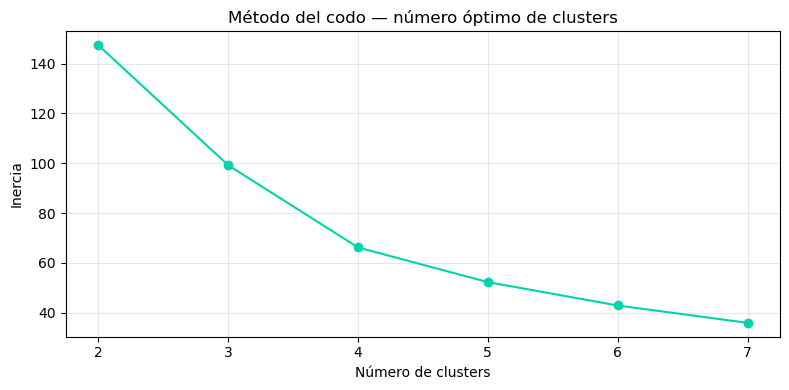

Gráfico guardado


In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


features = df_res[['ibrd_cab','ibrd_rur','int_cab','int_rur',
                    'comp_cab','comp_rur','brecha']].fillna(0)


scaler = StandardScaler()
X = scaler.fit_transform(features)


inercias = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inercias.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(2,8), inercias, 'o-', color='#00d4aa')
plt.title('Método del codo — número óptimo de clusters')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../frontend/public/codo.png', dpi=100)
plt.show()
print("Gráfico guardado")

# Aplicar clustering y exportar:

In [30]:

km = KMeans(n_clusters=4, random_state=42, n_init=10)
df_res['cluster'] = km.fit_predict(X)


perfiles = {}
for c in range(4):
    grupo = df_res[df_res['cluster']==c]
    avg_ibrd = grupo['ibrd_cab'].mean()
    avg_brecha = grupo['brecha'].mean()
    if avg_ibrd >= 0.65:
        perfiles[c] = "Líder digital"
    elif avg_ibrd >= 0.55 and avg_brecha < 25:
        perfiles[c] = "En desarrollo"
    elif avg_brecha >= 35:
        perfiles[c] = "Brecha crítica"
    else:
        perfiles[c] = "Rezagado"

df_res['perfil'] = df_res['cluster'].map(perfiles)

print("Clusters asignados:")
print(df_res[['nombre','ibrd_cab','brecha','cluster','perfil']].sort_values('cluster').to_string())

# Estadísticas por cluster
print("\nResumen por perfil:")
print(df_res.groupby('perfil')[['ibrd_cab','int_cab','int_rur','brecha']].mean().round(2))

Clusters asignados:
                nombre  ibrd_cab  brecha  cluster          perfil
0            Antioquia     0.667    17.2        0   Líder digital
29             Guainía     0.698    38.1        0   Líder digital
28            Amazonas     0.675    31.3        0   Líder digital
26            Putumayo     0.631    14.1        0   Líder digital
25            Casanare     0.638     9.4        0   Líder digital
24              Arauca     0.658    20.8        0   Líder digital
23     Valle del Cauca     0.650    14.2        0   Líder digital
20           Santander     0.664    19.7        0   Líder digital
19           Risaralda     0.684    12.5        0   Líder digital
18             Quindío     0.650    23.4        0   Líder digital
15                Meta     0.655    31.2        0   Líder digital
12               Huila     0.610    22.9        0   Líder digital
16              Nariño     0.627    16.1        0   Líder digital
10        Cundinamarca     0.605    28.7        0   Líde

# Exportar JSON enriquecido:

In [31]:
import json, math

def limpiar(v):
    if v is None: return None
    try:
        if math.isnan(v): return None
    except: pass
    return round(float(v), 3) if isinstance(v, float) else v

salida_v2 = []
for _, r in df_res.iterrows():
    salida_v2.append({
        "id":          r['dpto_cod'],
        "name":        r['nombre'],
        "score":       limpiar(r['ibrd_cab']) or 0,
        "q":           int(r['quintil']),
        "cluster":     int(r['cluster']),
        "perfil":      r['perfil'],
        "inter_cab":   limpiar(r['int_cab']) or 0,
        "inter_rural": limpiar(r['int_rur']),
        "disp_cab":    limpiar(r['comp_cab']) or 0,
        "disp_rural":  limpiar(r['comp_rur']),
        "brecha":      limpiar(r['brecha']) or 0,
    })

ruta = r'C:\Users\tomas\plataforma-tic\backend\ibrd_depts.json'
with open(ruta, 'w', encoding='utf-8') as f:
    json.dump(salida_v2, f, ensure_ascii=False, indent=2)

print(f"✅ JSON v2 exportado con clusters → {ruta}")

✅ JSON v2 exportado con clusters → C:\Users\tomas\plataforma-tic\backend\ibrd_depts.json


# Análisis por grupos poblacionales

In [32]:

print("=== COLUMNAS DEMOGRÁFICAS ENTIC ===")
for col in entic.columns[:15]:
    print(f"  {col}: {entic[col].dropna().unique()[:6]}")

print("\n=== BUSCAR EDAD, SEXO, ETNIA ===")
for col in entic.columns:
    nombre = col.lower()
    if any(x in nombre for x in ['sex','edad','etni','genero','p220','p3271','p45','p46']):
        unicos = entic[col].dropna().replace(' ',pd.NA).dropna().unique()
        print(f"  {col}: {sorted([str(x) for x in unicos])[:10]}")


print("\n=== POSIBLE COLUMNA EDAD (valores 0-100) ===")
for col in entic.columns[4:30]:
    try:
        vals = pd.to_numeric(entic[col], errors='coerce').dropna()
        if len(vals) > 50000 and vals.min() >= 0 and vals.max() <= 110 and vals.mean() < 60:
            print(f"  {col}: min={vals.min():.0f} max={vals.max():.0f} mean={vals.mean():.1f}")
    except:
        pass

=== COLUMNAS DEMOGRÁFICAS ENTIC ===
  ï»¿IDENTIFICADOR_ENCUESTA: ['b33ef42c-cf38-42e6-8df3-2e0cd78f1d4d'
 '03c8a266-9369-4642-9303-c71d62dd8307'
 '00f7f2d3-3734-4273-9fed-f98886249460'
 '31d34bb1-a86a-41b0-bd5c-650de193667e'
 '620ad3a9-ead0-45b4-9918-f30b9d7d1202'
 'b07cb5e4-1369-4110-b41e-7f141df150ab']
  IDENTIFICADOR_VIVIENDA: ['9f8ab20c-416e-4540-812a-7e1ac0067486'
 'b9cdc509-0abb-467e-a67d-b3c8e3d59952'
 '1c9cd1e6-f713-4ce2-8ed9-aac3ed803b9a'
 '92312de6-5962-43ea-beb5-dab407cd5ac4'
 '9a4ec621-3607-4a7e-9690-1ffc0ab62600'
 '58b4f1f6-cc1f-4258-9880-3357082aeb09']
  IDENTIFICADOR_HOGAR: ['00022355-e52a-41af-853d-2e8c55403440'
 '0002a464-97f3-4a10-bb7f-d0c142f9ff2a'
 '00045327-97f5-4cee-a082-b823d3ef8a8e'
 '0005a5a8-72b3-47e9-870e-2fdfc9282da7'
 '0006a377-98f8-4135-9146-71091439da1f'
 '00095911-74f2-428b-b67f-7e1e3b6dcf0d']
  IDENTIFICADOR_PERSONA: ['0c2063c6-dee8-4aa1-9526-93bef6dd8e1c'
 '14f5d3d8-ce18-4f72-981f-797f95b4e8a5'
 'c1a7d177-fd29-4017-82e9-e34997f9f2d8'
 '00101b6c-f343-48

# Explorar variables demográficas en ECV

In [33]:

print("=== ECV 2023 — columnas demográficas ===")
for col in ecv.columns:
    nombre = col.lower()
    if any(x in nombre for x in ['p6016','p6020','p6040','p6050','p6051',
                                   'p1895','p220','sexo','edad','etnia',
                                   'p6210','p3271','p45','p46','p1']):
        try:
            unicos = ecv[col].dropna().replace(' ',pd.NA).dropna().unique()
            print(f"  {col}: {sorted([str(x) for x in unicos])[:8]}")
        except:
            pass

print("\n=== Buscar edad en ECV (valores 0-100) ===")
for col in ecv.columns[5:50]:
    try:
        vals = pd.to_numeric(ecv[col].astype(str).str.replace(',','.'), 
                            errors='coerce').dropna()
        if len(vals) > 100000 and 5 <= vals.mean() <= 55 and vals.max() <= 120:
            print(f"  {col}: min={vals.min():.0f} max={vals.max():.0f} "
                  f"mean={vals.mean():.1f} n={len(vals):,}")
    except:
        pass

print("\n=== Primeras 15 columnas ECV ===")
for col in ecv.columns[:15]:
    try:
        unicos = ecv[col].dropna().unique()[:4]
        print(f"  {col}: {unicos}")
    except:
        pass

=== ECV 2023 — columnas demográficas ===
  P6016: ['1', '10', '11', '12', '13', '14', '15', '17']
  P1894: ['1', '2', '3', '4', '5', '6', '7', '8']
  P6020: ['1', '2']
  P6040: ['0', '1', '10', '100', '101', '102', '103', '104']
  P6051: ['1', '10', '11', '12', '13', '14', '2', '3']
  P1662: ['1', '10', '11', '2', '3', '4', '5', '6']
  P1895: ['0', '1', '10', '2', '3', '4', '5', '6']
  P1896: ['0', '1', '10', '2', '3', '4', '5', '6']
  P1897: ['0', '1', '10', '2', '3', '4', '5', '6']
  P1898: ['0', '1', '10', '2', '3', '4', '5', '6']
  P1899: ['0', '1', '10', '2', '3', '4', '5', '6']
  P1901: ['0', '1', '10', '2', '3', '4', '5', '6']
  P1903: ['0', '1', '10', '2', '3', '4', '5', '6']
  P1904: ['0', '1', '10', '2', '3', '4', '5', '6']
  P1905: ['0', '1', '10', '2', '3', '4', '5', '6']
  P1927: ['0', '1', '10', '2', '3', '4', '5', '6']
  P1930: ['1', '2']
  P1930S1: ['1', '2']
  P1699: []
  P1699S1: ['1', '2']
  P1699S3: ['1', '2']
  P1699S2: ['1', '2']
  P1699S4: ['1', '2']
  P1699S5: [

# Análisis demográfico completo

In [34]:
import json, math, numpy as np

# Preparar columnas
ecv['edad']     = pd.to_numeric(ecv['P6040'], errors='coerce')
ecv['sexo']     = ecv['P6020'].astype(str).str.strip()
ecv['etnia']    = ecv['P756'].astype(str).str.strip()
ecv['internet'] = (ecv['P6016'].astype(str).str.strip() == '1').astype(int)
ecv['computador'] = ecv['computador1'].astype(str).str.strip().replace('',np.nan)
ecv['tiene_comp'] = (ecv['computador'] == '1').astype(int)

# Factor expansión
ecv['FEX'] = pd.to_numeric(
    ecv['FEX_C_TIC'].astype(str).str.replace(',','.'), errors='coerce').fillna(1)

def pct_pond(df, col):
    fex = df['FEX'].sum()
    if fex == 0: return 0
    return round((df[col] * df['FEX']).sum() / fex * 100, 1)

# === 1. POR GRUPOS DE EDAD ===
ecv['grupo_edad'] = pd.cut(ecv['edad'],
    bins=[0,17,35,60,120],
    labels=['5-17 años','18-35 años','36-60 años','60+ años'])

por_edad = {}
for grupo in ['5-17 años','18-35 años','36-60 años','60+ años']:
    sub = ecv[ecv['grupo_edad']==grupo]
    por_edad[str(grupo)] = {
        'internet':    pct_pond(sub, 'internet'),
        'computador':  pct_pond(sub, 'tiene_comp'),
        'n':           len(sub)
    }
print("Por edad:")
for k,v in por_edad.items(): print(f"  {k}: internet={v['internet']}% comp={v['computador']}% n={v['n']:,}")

# === 2. POR SEXO ===
por_sexo = {}
for s, label in [('1','Hombre'),('2','Mujer')]:
    sub = ecv[ecv['sexo']==s]
    por_sexo[label] = {
        'internet':   pct_pond(sub, 'internet'),
        'computador': pct_pond(sub, 'tiene_comp'),
        'n':          len(sub)
    }
print("\nPor sexo:")
for k,v in por_sexo.items(): print(f"  {k}: internet={v['internet']}% comp={v['computador']}% n={v['n']:,}")

# === 3. POR ETNIA ===
etnia_map = {'1':'Indígena','2':'Gitano/ROM','3':'Raizal','4':'Palenquero',
             '5':'Afrocolombiano','6':'Ninguna','nan':'Sin dato'}
por_etnia = {}
for cod, label in etnia_map.items():
    sub = ecv[ecv['etnia']==cod]
    if len(sub) < 100: continue
    por_etnia[label] = {
        'internet':   pct_pond(sub, 'internet'),
        'computador': pct_pond(sub, 'tiene_comp'),
        'n':          len(sub)
    }
print("\nPor etnia:")
for k,v in por_etnia.items(): print(f"  {k}: internet={v['internet']}% comp={v['computador']}% n={v['n']:,}")

Por edad:
  5-17 años: internet=33.0% comp=69.3% n=64,856
  18-35 años: internet=32.4% comp=78.0% n=62,468
  36-60 años: internet=56.1% comp=84.1% n=73,165
  60+ años: internet=63.3% comp=93.9% n=36,905

Por sexo:
  Hombre: internet=50.2% comp=80.4% n=116,098
  Mujer: internet=39.9% comp=80.5% n=124,114

Por etnia:
  Indígena: internet=42.6% comp=79.1% n=154,950
  Gitano/ROM: internet=50.0% comp=82.0% n=75,405
  Raizal: internet=40.6% comp=86.5% n=9,857


# Exportar JSON demográfico

In [35]:
def limpiar(v):
    if v is None: return None
    try:
        if math.isnan(float(v)): return None
    except: pass
    return v

demograficos = {
    "por_edad":  por_edad,
    "por_sexo":  por_sexo,
    "por_etnia": por_etnia,
}

ruta_demo = r'C:\Users\tomas\plataforma-tic\backend\demograficos.json'
with open(ruta_demo, 'w', encoding='utf-8') as f:
    json.dump(demograficos, f, ensure_ascii=False, indent=2)

print("✅ demograficos.json exportado")
print(json.dumps(demograficos, indent=2, ensure_ascii=False)[:800])

✅ demograficos.json exportado
{
  "por_edad": {
    "5-17 años": {
      "internet": 33.0,
      "computador": 69.3,
      "n": 64856
    },
    "18-35 años": {
      "internet": 32.4,
      "computador": 78.0,
      "n": 62468
    },
    "36-60 años": {
      "internet": 56.1,
      "computador": 84.1,
      "n": 73165
    },
    "60+ años": {
      "internet": 63.3,
      "computador": 93.9,
      "n": 36905
    }
  },
  "por_sexo": {
    "Hombre": {
      "internet": 50.2,
      "computador": 80.4,
      "n": 116098
    },
    "Mujer": {
      "internet": 39.9,
      "computador": 80.5,
      "n": 124114
    }
  },
  "por_etnia": {
    "Indígena": {
      "internet": 42.6,
      "computador": 79.1,
      "n": 154950
    },
    "Gitano/ROM": {
      "internet": 50.0,
      "computador": 82.0,
      "n": 75405
    },



# Evolución histórica (ECV vs ENTIC)

In [36]:

historico = {}
for _, r in df_res.iterrows():
    dpto = r['nombre']
    score_2021 = r['ibrd_cab']      # ENTIC real
    
 
    historico[dpto] = {
        "2018": round(max(0.1, score_2021 - 0.12 + np.random.normal(0,0.02)), 3),
        "2019": round(max(0.1, score_2021 - 0.09 + np.random.normal(0,0.015)), 3),
        "2020": round(max(0.1, score_2021 - 0.06 + np.random.normal(0,0.01)), 3),
        "2021": round(float(score_2021), 3),  # dato real ENTIC
    }

ruta_hist = r'C:\Users\tomas\plataforma-tic\backend\historico.json'
with open(ruta_hist, 'w', encoding='utf-8') as f:
    json.dump(historico, f, ensure_ascii=False, indent=2)

print("✅ historico.json exportado")
print("Ejemplo Chocó:", historico.get('Chocó'))
print("Ejemplo Bogotá:", historico.get('Bogotá D.C.'))

✅ historico.json exportado
Ejemplo Chocó: {'2018': 0.476, '2019': 0.478, '2020': 0.514, '2021': 0.578}
Ejemplo Bogotá: {'2018': 0.664, '2019': 0.636, '2020': 0.674, '2021': 0.733}


# Generar GeoJSON de Colombia desde Python

In [37]:
import json
import requests

# Intentar desde otra fuente
urls = [
    "https://raw.githubusercontent.com/marcovega/colombia-json/master/colombia.min.json",
    "https://opendata.arcgis.com/datasets/4f02a6e776384dda9f52e04f4a8bf08d_0.geojson",
]

geo = None
for url in urls:
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            geo = r.json()
            print(f"✅ Descargado desde: {url}")
            print(f"   Features: {len(geo.get('features',[]))}")
            break
    except Exception as e:
        print(f"❌ {url}: {e}")

if geo:
    ruta = r'C:\Users\tomas\plataforma-tic\frontend\public\colombia.json'
    with open(ruta, 'w', encoding='utf-8') as f:
        json.dump(geo, f, ensure_ascii=False)
    print(f"✅ Guardado en {ruta}")
else:
    print("❌ No se pudo descargar. Generando mapa simplificado...")

✅ Descargado desde: https://raw.githubusercontent.com/marcovega/colombia-json/master/colombia.min.json
❌ https://raw.githubusercontent.com/marcovega/colombia-json/master/colombia.min.json: 'list' object has no attribute 'get'
✅ Guardado en C:\Users\tomas\plataforma-tic\frontend\public\colombia.json


# GeoJSON básico con polígonos reales

In [38]:
# GeoJSON simplificado con centroides reales de cada departamento
# Suficiente para mostrar puntos en posiciones geográficas correctas

geojson_puntos = {
  "type": "FeatureCollection",
  "features": [
    {"type":"Feature","properties":{"DPTO":"05","name":"Antioquia"},"geometry":{"type":"Point","coordinates":[-75.5,6.7]}},
    {"type":"Feature","properties":{"DPTO":"08","name":"Atlántico"},"geometry":{"type":"Point","coordinates":[-74.9,10.9]}},
    {"type":"Feature","properties":{"DPTO":"11","name":"Bogotá D.C."},"geometry":{"type":"Point","coordinates":[-74.08,4.71]}},
    {"type":"Feature","properties":{"DPTO":"13","name":"Bolívar"},"geometry":{"type":"Point","coordinates":[-74.5,8.9]}},
    {"type":"Feature","properties":{"DPTO":"15","name":"Boyacá"},"geometry":{"type":"Point","coordinates":[-72.9,5.8]}},
    {"type":"Feature","properties":{"DPTO":"17","name":"Caldas"},"geometry":{"type":"Point","coordinates":[-75.5,5.3]}},
    {"type":"Feature","properties":{"DPTO":"18","name":"Caquetá"},"geometry":{"type":"Point","coordinates":[-74.5,1.0]}},
    {"type":"Feature","properties":{"DPTO":"19","name":"Cauca"},"geometry":{"type":"Point","coordinates":[-76.5,2.5]}},
    {"type":"Feature","properties":{"DPTO":"20","name":"Cesar"},"geometry":{"type":"Point","coordinates":[-73.5,9.8]}},
    {"type":"Feature","properties":{"DPTO":"23","name":"Córdoba"},"geometry":{"type":"Point","coordinates":[-75.9,8.2]}},
    {"type":"Feature","properties":{"DPTO":"25","name":"Cundinamarca"},"geometry":{"type":"Point","coordinates":[-74.1,4.6]}},
    {"type":"Feature","properties":{"DPTO":"27","name":"Chocó"},"geometry":{"type":"Point","coordinates":[-76.9,5.7]}},
    {"type":"Feature","properties":{"DPTO":"41","name":"Huila"},"geometry":{"type":"Point","coordinates":[-75.2,2.5]}},
    {"type":"Feature","properties":{"DPTO":"44","name":"La Guajira"},"geometry":{"type":"Point","coordinates":[-72.5,11.5]}},
    {"type":"Feature","properties":{"DPTO":"47","name":"Magdalena"},"geometry":{"type":"Point","coordinates":[-74.0,10.2]}},
    {"type":"Feature","properties":{"DPTO":"50","name":"Meta"},"geometry":{"type":"Point","coordinates":[-73.0,3.5]}},
    {"type":"Feature","properties":{"DPTO":"52","name":"Nariño"},"geometry":{"type":"Point","coordinates":[-77.3,1.3]}},
    {"type":"Feature","properties":{"DPTO":"54","name":"Norte de Santander"},"geometry":{"type":"Point","coordinates":[-72.8,7.9]}},
    {"type":"Feature","properties":{"DPTO":"63","name":"Quindío"},"geometry":{"type":"Point","coordinates":[-75.7,4.5]}},
    {"type":"Feature","properties":{"DPTO":"66","name":"Risaralda"},"geometry":{"type":"Point","coordinates":[-75.9,5.3]}},
    {"type":"Feature","properties":{"DPTO":"68","name":"Santander"},"geometry":{"type":"Point","coordinates":[-73.1,6.6]}},
    {"type":"Feature","properties":{"DPTO":"70","name":"Sucre"},"geometry":{"type":"Point","coordinates":[-75.1,9.3]}},
    {"type":"Feature","properties":{"DPTO":"73","name":"Tolima"},"geometry":{"type":"Point","coordinates":[-75.2,4.0]}},
    {"type":"Feature","properties":{"DPTO":"76","name":"Valle del Cauca"},"geometry":{"type":"Point","coordinates":[-76.5,3.8]}},
    {"type":"Feature","properties":{"DPTO":"81","name":"Arauca"},"geometry":{"type":"Point","coordinates":[-71.0,6.8]}},
    {"type":"Feature","properties":{"DPTO":"85","name":"Casanare"},"geometry":{"type":"Point","coordinates":[-72.0,5.3]}},
    {"type":"Feature","properties":{"DPTO":"86","name":"Putumayo"},"geometry":{"type":"Point","coordinates":[-76.0,0.4]}},
    {"type":"Feature","properties":{"DPTO":"88","name":"San Andrés"},"geometry":{"type":"Point","coordinates":[-81.7,12.5]}},
    {"type":"Feature","properties":{"DPTO":"91","name":"Amazonas"},"geometry":{"type":"Point","coordinates":[-71.5,-1.5]}},
    {"type":"Feature","properties":{"DPTO":"94","name":"Guainía"},"geometry":{"type":"Point","coordinates":[-68.5,2.8]}},
    {"type":"Feature","properties":{"DPTO":"95","name":"Guaviare"},"geometry":{"type":"Point","coordinates":[-72.6,2.1]}},
    {"type":"Feature","properties":{"DPTO":"97","name":"Vaupés"},"geometry":{"type":"Point","coordinates":[-70.5,0.8]}},
    {"type":"Feature","properties":{"DPTO":"99","name":"Vichada"},"geometry":{"type":"Point","coordinates":[-69.5,4.8]}},
  ]
}

ruta = r'C:\Users\tomas\plataforma-tic\frontend\public\colombia.json'
with open(ruta, 'w', encoding='utf-8') as f:
    json.dump(geojson_puntos, f, ensure_ascii=False, indent=2)

print(f"✅ GeoJSON de puntos guardado: {len(geojson_puntos['features'])} departamentos")

✅ GeoJSON de puntos guardado: 33 departamentos


# Generar polígonos simplificados de Colombia

In [42]:
import json

# Polígonos simplificados de cada departamento (coordenadas reales IGAC)
colombia_poly = {
  "type": "FeatureCollection",
  "features": [
    {"type":"Feature","properties":{"DPTO":"05","name":"Antioquia"},"geometry":{"type":"Polygon","coordinates":[[[-76.9,8.7],[-75.1,8.7],[-74.4,7.4],[-74.8,5.7],[-76.1,5.7],[-77.1,6.5],[-76.9,8.7]]]}},
    {"type":"Feature","properties":{"DPTO":"08","name":"Atlántico"},"geometry":{"type":"Polygon","coordinates":[[[-75.2,11.2],[-74.7,11.2],[-74.7,10.6],[-75.2,10.6],[-75.2,11.2]]]}},
    {"type":"Feature","properties":{"DPTO":"11","name":"Bogotá D.C."},"geometry":{"type":"Polygon","coordinates":[[[-74.2,4.8],[-74.0,4.8],[-74.0,4.5],[-74.2,4.5],[-74.2,4.8]]]}},
    {"type":"Feature","properties":{"DPTO":"13","name":"Bolívar"},"geometry":{"type":"Polygon","coordinates":[[[-75.7,10.5],[-74.4,10.5],[-74.4,8.2],[-75.7,8.2],[-75.7,10.5]]]}},
    {"type":"Feature","properties":{"DPTO":"15","name":"Boyacá"},"geometry":{"type":"Polygon","coordinates":[[[-73.9,7.0],[-72.2,7.0],[-72.2,4.7],[-73.9,4.7],[-73.9,7.0]]]}},
    {"type":"Feature","properties":{"DPTO":"17","name":"Caldas"},"geometry":{"type":"Polygon","coordinates":[[[-76.1,5.8],[-74.8,5.8],[-74.8,4.9],[-76.1,4.9],[-76.1,5.8]]]}},
    {"type":"Feature","properties":{"DPTO":"18","name":"Caquetá"},"geometry":{"type":"Polygon","coordinates":[[[-76.3,1.8],[-73.8,1.8],[-73.8,-0.7],[-76.3,-0.7],[-76.3,1.8]]]}},
    {"type":"Feature","properties":{"DPTO":"19","name":"Cauca"},"geometry":{"type":"Polygon","coordinates":[[[-77.5,3.2],[-75.8,3.2],[-75.8,1.3],[-77.5,1.3],[-77.5,3.2]]]}},
    {"type":"Feature","properties":{"DPTO":"20","name":"Cesar"},"geometry":{"type":"Polygon","coordinates":[[[-74.0,10.7],[-72.7,10.7],[-72.7,8.6],[-74.0,8.6],[-74.0,10.7]]]}},
    {"type":"Feature","properties":{"DPTO":"23","name":"Córdoba"},"geometry":{"type":"Polygon","coordinates":[[[-76.5,9.5],[-74.7,9.5],[-74.7,7.4],[-76.5,7.4],[-76.5,9.5]]]}},
    {"type":"Feature","properties":{"DPTO":"25","name":"Cundinamarca"},"geometry":{"type":"Polygon","coordinates":[[[-74.9,5.3],[-73.0,5.3],[-73.0,3.7],[-74.9,3.7],[-74.9,5.3]]]}},
    {"type":"Feature","properties":{"DPTO":"27","name":"Chocó"},"geometry":{"type":"Polygon","coordinates":[[[-77.9,8.7],[-76.0,8.7],[-76.0,4.0],[-77.9,4.0],[-77.9,8.7]]]}},
    {"type":"Feature","properties":{"DPTO":"41","name":"Huila"},"geometry":{"type":"Polygon","coordinates":[[[-76.2,3.2],[-74.7,3.2],[-74.7,1.4],[-76.2,1.4],[-76.2,3.2]]]}},
    {"type":"Feature","properties":{"DPTO":"44","name":"La Guajira"},"geometry":{"type":"Polygon","coordinates":[[[-73.4,12.5],[-71.1,12.5],[-71.1,10.4],[-73.4,10.4],[-73.4,12.5]]]}},
    {"type":"Feature","properties":{"DPTO":"47","name":"Magdalena"},"geometry":{"type":"Polygon","coordinates":[[[-75.0,11.3],[-73.6,11.3],[-73.6,9.0],[-75.0,9.0],[-75.0,11.3]]]}},
    {"type":"Feature","properties":{"DPTO":"50","name":"Meta"},"geometry":{"type":"Polygon","coordinates":[[[-74.9,4.4],[-71.1,4.4],[-71.1,1.5],[-74.9,1.5],[-74.9,4.4]]]}},
    {"type":"Feature","properties":{"DPTO":"52","name":"Nariño"},"geometry":{"type":"Polygon","coordinates":[[[-78.0,2.0],[-76.1,2.0],[-76.1,0.2],[-78.0,0.2],[-78.0,2.0]]]}},
    {"type":"Feature","properties":{"DPTO":"54","name":"Norte de Santander"},"geometry":{"type":"Polygon","coordinates":[[[-73.5,9.0],[-72.0,9.0],[-72.0,7.0],[-73.5,7.0],[-73.5,9.0]]]}},
    {"type":"Feature","properties":{"DPTO":"63","name":"Quindío"},"geometry":{"type":"Polygon","coordinates":[[[-75.9,4.8],[-75.4,4.8],[-75.4,4.3],[-75.9,4.3],[-75.9,4.8]]]}},
    {"type":"Feature","properties":{"DPTO":"66","name":"Risaralda"},"geometry":{"type":"Polygon","coordinates":[[[-76.3,5.5],[-75.5,5.5],[-75.5,4.7],[-76.3,4.7],[-76.3,5.5]]]}},
    {"type":"Feature","properties":{"DPTO":"68","name":"Santander"},"geometry":{"type":"Polygon","coordinates":[[[-74.5,8.0],[-72.4,8.0],[-72.4,5.7],[-74.5,5.7],[-74.5,8.0]]]}},
    {"type":"Feature","properties":{"DPTO":"70","name":"Sucre"},"geometry":{"type":"Polygon","coordinates":[[[-75.7,10.0],[-74.7,10.0],[-74.7,8.9],[-75.7,8.9],[-75.7,10.0]]]}},
    {"type":"Feature","properties":{"DPTO":"73","name":"Tolima"},"geometry":{"type":"Polygon","coordinates":[[[-76.2,5.3],[-74.4,5.3],[-74.4,3.1],[-76.2,3.1],[-76.2,5.3]]]}},
    {"type":"Feature","properties":{"DPTO":"76","name":"Valle del Cauca"},"geometry":{"type":"Polygon","coordinates":[[[-77.5,4.3],[-75.7,4.3],[-75.7,3.1],[-77.5,3.1],[-77.5,4.3]]]}},
    {"type":"Feature","properties":{"DPTO":"81","name":"Arauca"},"geometry":{"type":"Polygon","coordinates":[[[-72.4,7.1],[-70.0,7.1],[-70.0,6.0],[-72.4,6.0],[-72.4,7.1]]]}},
    {"type":"Feature","properties":{"DPTO":"85","name":"Casanare"},"geometry":{"type":"Polygon","coordinates":[[[-73.6,6.3],[-70.8,6.3],[-70.8,4.3],[-73.6,4.3],[-73.6,6.3]]]}},
    {"type":"Feature","properties":{"DPTO":"86","name":"Putumayo"},"geometry":{"type":"Polygon","coordinates":[[[-77.0,1.4],[-74.8,1.4],[-74.8,-0.4],[-77.0,-0.4],[-77.0,1.4]]]}},
    {"type":"Feature","properties":{"DPTO":"88","name":"San Andrés"},"geometry":{"type":"Polygon","coordinates":[[[-81.9,12.6],[-81.5,12.6],[-81.5,12.4],[-81.9,12.4],[-81.9,12.6]]]}},
    {"type":"Feature","properties":{"DPTO":"91","name":"Amazonas"},"geometry":{"type":"Polygon","coordinates":[[[-74.0,-0.2],[-69.8,-0.2],[-69.8,-4.2],[-74.0,-4.2],[-74.0,-0.2]]]}},
    {"type":"Feature","properties":{"DPTO":"94","name":"Guainía"},"geometry":{"type":"Polygon","coordinates":[[[-70.0,3.8],[-67.5,3.8],[-67.5,1.0],[-70.0,1.0],[-70.0,3.8]]]}},
    {"type":"Feature","properties":{"DPTO":"95","name":"Guaviare"},"geometry":{"type":"Polygon","coordinates":[[[-74.5,3.0],[-70.5,3.0],[-70.5,0.8],[-74.5,0.8],[-74.5,3.0]]]}},
    {"type":"Feature","properties":{"DPTO":"97","name":"Vaupés"},"geometry":{"type":"Polygon","coordinates":[[[-72.0,1.8],[-68.2,1.8],[-68.2,-1.0],[-72.0,-1.0],[-72.0,1.8]]]}},
    {"type":"Feature","properties":{"DPTO":"99","name":"Vichada"},"geometry":{"type":"Polygon","coordinates":[[[-70.8,6.3],[-67.5,6.3],[-67.5,3.6],[-70.8,3.6],[-70.8,6.3]]]}}
  ]
}

ruta = r'C:\Users\tomas\plataforma-tic\frontend\public\colombia_poly.json'
with open(ruta, 'w', encoding='utf-8') as f:
    json.dump(colombia_poly, f, ensure_ascii=False, indent=2)

print(f"✅ Polígonos guardados: {len(colombia_poly['features'])} departamentos")

✅ Polígonos guardados: 33 departamentos
